# PCA

In [25]:
import numpy as np
import pandas as pd
np.random.seed(23)

In [26]:
mu_vec1=np.array([0,0,0])
cov_mat1=np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample=np.random.multivariate_normal(mu_vec1,cov_mat1,20)

In [27]:
class1_sample

array([[ 0.66698806,  0.02581308, -0.77761941],
       [ 0.94863382,  0.70167179, -1.05108156],
       [-0.36754812, -1.13745969, -1.32214752],
       [ 1.77225828, -0.34745899,  0.67014016],
       [ 0.32227152,  0.06034293, -1.04345   ],
       [-1.00994188,  0.44173637,  1.12887685],
       [-1.83806777, -0.93876863, -0.20184052],
       [ 1.04537128,  0.53816197,  0.81211867],
       [ 0.2411063 , -0.95250953, -0.13626676],
       [ 1.26724821,  0.17363364, -1.22325477],
       [ 1.41531998,  0.45771098,  0.72887584],
       [ 1.96843473, -0.54778801, -0.67941827],
       [-2.50623032,  0.14696049,  0.60619549],
       [-0.02253889,  0.01342226,  0.93594489],
       [ 0.42062266,  0.41161964, -0.07132392],
       [-0.04543758,  1.04088597, -0.09403473],
       [-0.42084395, -0.55198856, -0.12109755],
       [ 0.19014136,  0.51213739,  0.13153847],
       [-0.33161712, -1.63238628,  0.61911407],
       [-0.99257378, -0.16134639,  1.19240433]])

In [28]:
df=pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target']=1

In [29]:
df

,feature1,feature2,feature3,target
0,0.666988,0.025813,-0.777619,1
1,0.948634,0.701672,-1.051082,1
2,-0.367548,-1.137460,-1.322148,1
3,1.772258,-0.347459,0.670140,1
4,0.322272,0.060343,-1.043450,1
5,-1.009942,0.441736,1.128877,1
6,-1.838068,-0.938769,-0.201841,1
7,1.045371,0.538162,0.812119,1
8,0.241106,-0.952510,-0.136267,1
9,1.267248,0.173634,-1.223255,1


In [33]:
mu_vec2=np.array([1,1,1])
cov_mat2=np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample=np.random.multivariate_normal(mu_vec2,cov_mat2,20)
df1=pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])
df1['target']=0
df=pd.concat([df,df1],ignore_index=True)
df=df.sample(40)

In [34]:
df.target.value_counts()

target
0    29
1    11
Name: count, dtype: int64

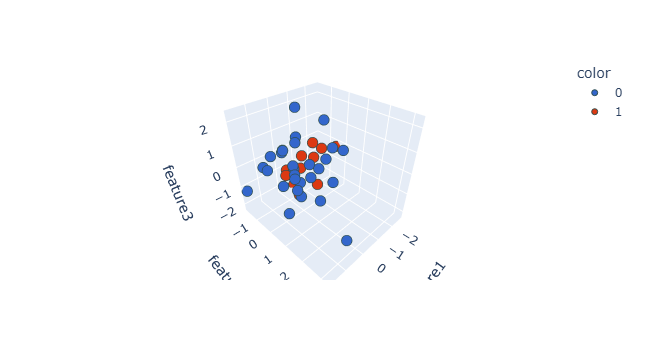

In [60]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='feature1',
    y='feature2',
    z='feature3',
    color=df['target'].astype('str'),
    color_discrete_sequence=px.colors.qualitative.G10
)

fig.update_traces(
    marker=dict(
        size=6,
        line=dict(width=1, color='DarkSlateGrey')
    )
)

fig.show()

In [38]:
# step-1 apply standard scalling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
df.iloc[:,0:3]=scaler.fit_transform(df.iloc[:,0:3])

In [41]:
# step2- find covariance matrix
covariance_matrix=np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('covariance matrix:\n',covariance_matrix)

covariance matrix:
 [[1.02564103 0.24218106 0.10155813]
 [0.24218106 1.02564103 0.23545585]
 [0.10155813 0.23545585 1.02564103]]


In [43]:
# step3-finding EV AND EVs
eigen_values,eigen_vectors=np.linalg.eig(covariance_matrix)

In [44]:
eigen_values

array([1.41797584, 0.92413204, 0.7348152 ])

In [45]:
eigen_vectors

array([[-0.54029826, -0.69481491,  0.47466835],
       [-0.6524391 , -0.01033092, -0.75777074],
       [-0.53141417,  0.7191144 ,  0.44774264]])

In [46]:
%pylab inline
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


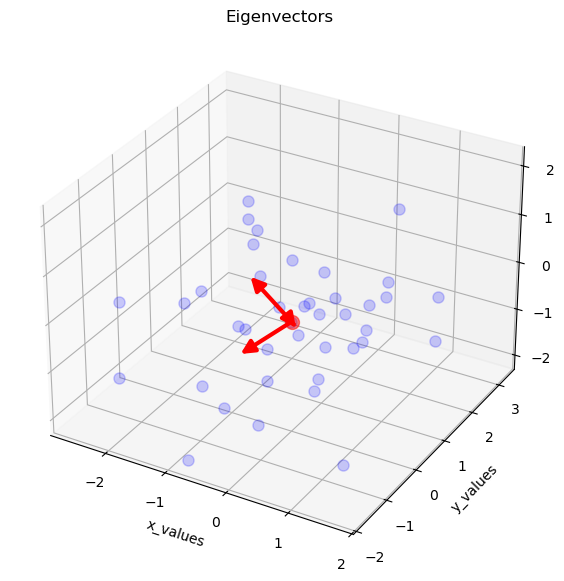

In [55]:
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.get_proj())
        self.set_positions((xs[0], ys[0]), (xs[1], ys[1]))
        super().draw(renderer)

    # ✅ ADD THIS METHOD (IMPORTANT)
    def do_3d_projection(self, renderer=None):
        return 0

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([df['feature1'].mean()], [df['feature2'].mean()], [df['feature3'].mean()], 'o', markersize=10, color='red', alpha=0.5)
for v in eigen_vectors.T:
    a = Arrow3D([df['feature1'].mean(), v[0]], [df['feature2'].mean(), v[1]], [df['feature3'].mean(), v[2]], mutation_scale=20, lw=3, arrowstyle="-|>", color="r")
    ax.add_artist(a)
ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')

plt.title('Eigenvectors')

plt.show()

In [54]:
pc=eigen_vectors[0:2]
pc

array([[-0.54029826, -0.69481491,  0.47466835],
       [-0.6524391 , -0.01033092, -0.75777074]])

In [56]:
transformed_df=np.dot(df.iloc[:,0:3],pc.T)
new_df=pd.DataFrame(transformed_df,columns=['pc1','pc2'])
new_df['target']=df['target'].values
new_df

,pc1,pc2,target
0,1.148598,-0.884639,0
1,0.187134,0.274431,0
2,1.024225,0.703706,1
3,-1.082521,-0.361468,0
4,0.208806,0.110245,0
5,-0.422843,-2.337614,0
6,-0.283208,-1.913932,0
7,-0.829786,-0.818460,0
8,-3.170222,0.129356,0
9,-2.035327,-0.761752,0


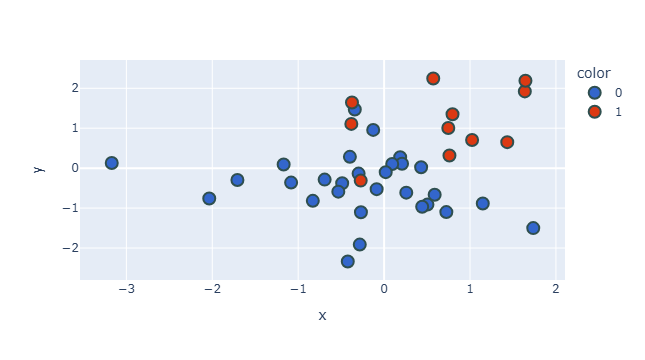

In [57]:
new_df['target']=new_df['target'].astype('str')
fig=px.scatter(x=new_df['pc1'],y=new_df['pc2'],color=new_df['target'],
              color_discrete_sequence=px.colors.qualitative.G10)
fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGrey')),
                 selector=dict(mode='markers'))
fig.show()